Ноутбук: Анализ retrieval-методов (BM25, Dense, Hybrid, SPLADE, Triple Hybrid)
1. Введение
В этом ноутбуке мы сравниваем пять методов поиска:

BM25 – лексический baseline со стеммингом (Porter)

Dense – семантический поиск (e5-small-v2)

Hybrid BM25+Dense – объединение ранжирований через RRF

SPLADE – разреженный нейросетевой поиск

Triple Hybrid – RRF всех трёх методов

Оценка производится на уровне документов: каждый чанк маппится на документ, дубликаты документов в выдаче удаляются (учитывается только первое появление).
Метрики: Recall@k, NDCG@k, MRR@k для k ∈ {1, 5, 10, 100, 1000}.
Дополнительно проводятся парные статистические тесты (Wilcoxon signed-rank с поправкой Холма) и бутстраповские доверительные интервалы.



**Реранкинг.** Поверх классического ретрива (кандидатный пул top-1000) добавляются два кросс-энкодер реранкера, которые пересортировывают кандидатов и возвращают top-100. Реранкеры сравниваются между собой и с базовым ретривом по тем же метрикам и той же статистике (Wilcoxon + поправка Холма).

In [1]:
#!pip install seaborn

In [2]:
import os
import pickle
import warnings
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Конфигурация (пути к файлам)
CHUNKS_PARQUET = "chunks_fixed_v1.parquet"
QUESTIONS_PARQUET = "questions_for_sample.parquet"
BM25_RESULTS_PKL = "retrieval_results/bm25_stemming_chunks_top1000.pkl"
DENSE_RESULTS_PKL = "retrieval_results/dense_chunks_top1000.pkl"
SPLADE_RESULTS_PKL = "splade_results_from_index.pkl"

K_VALUES = [1, 5, 10, 100, 1000]
RRF_K = 60
RANDOM_SEED = 42
ALPHA = 0.05
np.random.seed(RANDOM_SEED)

# Папка для сохранения графиков
OUT_DIR = "retrieval_analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

print("Настройки загружены.")

Настройки загружены.


## Даннык

In [3]:
def load_ground_truth():
    df_chunks = pd.read_parquet(CHUNKS_PARQUET)
    df_questions = pd.read_parquet(QUESTIONS_PARQUET)
    chunk_to_doc = dict(zip(df_chunks["chunk_id"], df_chunks["doc_id"]))
    expected_doc_ids_by_qid = {
        row["question_id"]: set(row["expected_doc_ids"])
        for _, row in df_questions.iterrows()
    }
    qids_order = list(df_questions["question_id"])
    return chunk_to_doc, expected_doc_ids_by_qid, qids_order

chunk_to_doc, expected_doc_ids_by_qid, qids_order = load_ground_truth()
print(f"Загружено {len(chunk_to_doc)} чанков, {len(expected_doc_ids_by_qid)} запросов.")

Загружено 570005 чанков, 138 запросов.


In [4]:
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

bm25_results = load_pkl(BM25_RESULTS_PKL)
dense_results = load_pkl(DENSE_RESULTS_PKL)
splade_results = load_pkl(SPLADE_RESULTS_PKL)

print(f"BM25: {len(bm25_results)} запросов")
print(f"Dense: {len(dense_results)} запросов")
print(f"SPLADE: {len(splade_results)} запросов")

BM25: 138 запросов
Dense: 138 запросов
SPLADE: 138 запросов


In [5]:
def reciprocal_rank_fusion(rankings, k=RRF_K):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, chunk_id in enumerate(ranking):
            scores[chunk_id] += 1.0 / (k + rank + 1)
    return [cid for cid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

def build_hybrid_results(bm25_results, dense_results, splade_results, top_k=1000):
    hybrid_bd = {}
    triple = {}
    for qid in bm25_results:
        if qid not in dense_results:
            continue
        hybrid_bd[qid] = reciprocal_rank_fusion(
            [bm25_results[qid], dense_results[qid]], k=RRF_K
        )[:top_k]
        if qid in splade_results:
            triple[qid] = reciprocal_rank_fusion(
                [bm25_results[qid], dense_results[qid], splade_results[qid]], k=RRF_K
            )[:top_k]
    return hybrid_bd, triple

hybrid_bd, triple = build_hybrid_results(bm25_results, dense_results, splade_results)
print(f"Hybrid BM25+Dense: {len(hybrid_bd)} запросов")
print(f"Triple Hybrid: {len(triple)} запросов")

Hybrid BM25+Dense: 138 запросов
Triple Hybrid: 138 запросов


In [6]:
def compute_metrics_doc_level_per_query(retrieved_lists, chunk_to_doc, expected_doc_ids, k_values=K_VALUES):
    per_k = {k: {} for k in k_values}
    for qid, expected_docs in expected_doc_ids.items():
        if qid not in retrieved_lists or not expected_docs:
            continue
        full_retrieved = retrieved_lists[qid]
        for k in k_values:
            retrieved_chunks = full_retrieved[:k]
            seen_docs, seen_set = [], set()
            for chunk_id in retrieved_chunks:
                doc_id = chunk_to_doc.get(chunk_id)
                if doc_id is not None and doc_id not in seen_set:
                    seen_set.add(doc_id)
                    seen_docs.append(doc_id)
            n_expected = len(expected_docs)
            n_found = len(seen_set & expected_docs)
            recall = n_found / n_expected
            dcg = sum((1.0 if doc_id in expected_docs else 0.0) / np.log2(i + 2)
                      for i, doc_id in enumerate(seen_docs))
            ideal_rels = [1.0] * min(n_expected, k)
            idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_rels))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            rr = 0.0
            for i, doc_id in enumerate(seen_docs):
                if doc_id in expected_docs:
                    rr = 1.0 / (i + 1)
                    break
            per_k[k][qid] = {"Recall": recall, "NDCG": ndcg, "MRR": rr}
    return {k: pd.DataFrame.from_dict(v, orient="index") for k, v in per_k.items()}

# Собираем все методы в один словарь
methods_results = {
    "BM25": bm25_results,
    "Dense": dense_results,
    "Hybrid BM25+Dense": hybrid_bd,
    "SPLADE": splade_results,
    "Triple Hybrid": triple,
}

per_query_by_method = {}
for name, results in methods_results.items():
    per_query_by_method[name] = compute_metrics_doc_level_per_query(
        results, chunk_to_doc, expected_doc_ids_by_qid, K_VALUES
    )
    print(f"{name}: вычислено для {len(per_query_by_method[name][1])} запросов")

BM25: вычислено для 138 запросов
Dense: вычислено для 138 запросов
Hybrid BM25+Dense: вычислено для 138 запросов
SPLADE: вычислено для 138 запросов
Triple Hybrid: вычислено для 138 запросов


In [7]:
def aggregate_table(per_query_by_method):
    rows = []
    for method, per_k in per_query_by_method.items():
        for k, df in per_k.items():
            rows.append({
                "Method": method, "k": k,
                "Recall@k": df["Recall"].mean(),
                "NDCG@k": df["NDCG"].mean(),
                "MRR@k": df["MRR"].mean(),
                "n_queries": len(df),
            })
    return pd.DataFrame(rows)

comparison_df = aggregate_table(per_query_by_method)
print("Сводная таблица средних метрик:")
display(comparison_df.round(4))

# Pivot для удобства
for metric in ["Recall@k", "NDCG@k", "MRR@k"]:
    print(f"\n{metric}")
    display(comparison_df.pivot(index="Method", columns="k", values=metric).round(4))

Сводная таблица средних метрик:


,Method,k,Recall@k,NDCG@k,MRR@k,n_queries
0,BM25,1,0.3875,0.5000,0.5000,138
1,BM25,5,0.5338,0.5054,0.5886,138
2,BM25,10,0.5689,0.5127,0.5948,138
3,BM25,100,0.6746,0.5371,0.6008,138
4,BM25,1000,0.7208,0.5440,0.6012,138
5,Dense,1,0.2414,0.3188,0.3188,138
6,Dense,5,0.3977,0.3554,0.4115,138
7,Dense,10,0.4501,0.3706,0.4196,138
8,Dense,100,0.5526,0.3942,0.4251,138
9,Dense,1000,0.6674,0.4094,0.4257,138



Recall@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.3875,0.5338,0.5689,0.6746,0.7208
Dense,0.2414,0.3977,0.4501,0.5526,0.6674
Hybrid BM25+Dense,0.4042,0.5141,0.5653,0.6674,0.7198
SPLADE,0.3788,0.5085,0.5673,0.6474,0.7099
Triple Hybrid,0.3984,0.5627,0.5987,0.6766,0.7290



NDCG@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5054,0.5127,0.5371,0.5440
Dense,0.3188,0.3554,0.3706,0.3942,0.4094
Hybrid BM25+Dense,0.5290,0.5009,0.5151,0.5398,0.5476
SPLADE,0.4710,0.4794,0.4965,0.5169,0.5255
Triple Hybrid,0.5290,0.5243,0.5340,0.5550,0.5628



MRR@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5886,0.5948,0.6008,0.6012
Dense,0.3188,0.4115,0.4196,0.4251,0.4257
Hybrid BM25+Dense,0.5290,0.5944,0.6045,0.6111,0.6115
SPLADE,0.4710,0.5478,0.5569,0.5616,0.5621
Triple Hybrid,0.5290,0.6098,0.6155,0.6224,0.6229


## Реранкинг: выбор моделей

К классическому ретриву добавляем два реранкера, которые пересортировывают top-1000 кандидатов и оставляют top-100:

1. **`cross-encoder/ms-marco-MiniLM-L6-v2`** — лёгкий кросс-энкодер (22M параметров). На CPU без квантизации даёт разумную задержку даже на пуле 1000 документов × 138 запросов (~138k пар). Обучен на MS MARCO (английский), хорошо подходит как быстрый baseline-реранкер для Jira/Confluence/писем на английском.
2. **`BAAI/bge-reranker-v2-m3`** — современный сильный реранкер поверх многоязычной BGE-M3 (поддерживает RU/EN и смешанные корпоративные корпуса, длинный контекст до 8192 токенов, что полезно для крупных чанков Confluence). Существенно тяжелее MiniLM, поэтому интересен как верхняя граница качества при более высокой задержке.

Пара специально выбрана как компромисс "скорость vs качество": если статистически значимой разницы между ними нет, для продакшена на CPU разумнее взять более лёгкий MiniLM.

**Кандидатный пул для реранжирования.** Реранкер не может найти документ, которого нет в поданных ему кандидатах, поэтому пул на входе выбирается по **Recall@1000** среди уже посчитанных классических методов (BM25/Dense/Hybrid/SPLADE/Triple Hybrid), а не по NDCG@1000 — нас интересует потолок по recall, а сортировку внутри пула всё равно переопределит реранкер.

**Важно про k.** Реранкеры возвращают не более 100 документов на запрос, поэтому в таблицах и графиках ниже метрики при k=100 и k=1000 для реранкеров совпадают (список просто короче k).

In [8]:
# ==== Тексты запросов и чанков для реранкера ====

def load_texts():
    df_chunks = pd.read_parquet(CHUNKS_PARQUET)
    df_questions = pd.read_parquet(QUESTIONS_PARQUET)

    def _find_col(df, candidates, label):
        for c in candidates:
            if c in df.columns:
                return c
        raise KeyError(
            f"Не найдена текстовая колонка для {label}. "
            f"Доступные колонки: {list(df.columns)}. "
            f"Добавьте нужное имя в список candidates."
        )

    q_col = _find_col(
        df_questions,
        ["question_text", "query_text", "question", "query", "text"],
        "questions_for_sample.parquet",
    )
    c_col = _find_col(
        df_chunks,
        ["chunk_text", "text", "content", "chunk_content", "body"],
        "chunks_fixed_v1.parquet",
    )
    print(f"Колонка текста вопроса: '{q_col}'; колонка текста чанка: '{c_col}'")

    query_text_by_qid = dict(zip(df_questions["question_id"], df_questions[q_col]))
    chunk_text_by_id = dict(zip(df_chunks["chunk_id"], df_chunks[c_col]))
    return query_text_by_qid, chunk_text_by_id

query_text_by_qid, chunk_text_by_id = load_texts()
print(f"Текстов запросов: {len(query_text_by_qid)}, текстов чанков: {len(chunk_text_by_id)}")

Колонка текста вопроса: 'question'; колонка текста чанка: 'chunk_text'
Текстов запросов: 138, текстов чанков: 570005


In [9]:
# ==== Кандидатный пул для реранжирования: метод с лучшим Recall@1000 ====

recall_at_1000 = (
    comparison_df[comparison_df["k"] == 1000]
    .set_index("Method")["Recall@k"]
)
base_method_name = recall_at_1000.idxmax()

print("Recall@1000 по методам:")
print(recall_at_1000.round(4).sort_values(ascending=False))
print(f"\nВыбран кандидатный пул для реранжирования: '{base_method_name}' "
      f"(Recall@1000 = {recall_at_1000.max():.4f})")

# Реранкать все 1000 кандидатов ради top-100 на выходе — избыточно и в разы
# медленнее без пользы: документы за пределами top-150..200 по классическому
# ретриву почти никогда не всплывают в top-100 после реранка. Обрезка глубины —
# самый дешёвый и линейный по эффекту рычаг скорости.
RERANK_INPUT_DEPTH = 1000

base_candidates_full = methods_results[base_method_name]  # qid -> [chunk_id, ...] (top-1000)
base_candidates = {qid: docs[:RERANK_INPUT_DEPTH] for qid, docs in base_candidates_full.items()}

recall_at_100 = comparison_df[
    (comparison_df["Method"] == base_method_name) & (comparison_df["k"] == 100)
]["Recall@k"].values[0]
print(f"\nГлубина входа реранкера обрезана до top-{RERANK_INPUT_DEPTH} "
      f"(~{RERANK_INPUT_DEPTH / 1000:.0%} от прежнего объёма вычислений).\n"
      f"Верхняя граница потери потолка recall: Recall@100 = {recall_at_100:.4f} "
      f"vs Recall@1000 = {recall_at_1000.max():.4f} у '{base_method_name}' "
      f"(реальная потеря на глубине {RERANK_INPUT_DEPTH} будет меньше этой разницы).")

Recall@1000 по методам:
Method
Triple Hybrid        0.7290
BM25                 0.7208
Hybrid BM25+Dense    0.7198
SPLADE               0.7099
Dense                0.6674
Name: Recall@k, dtype: float64

Выбран кандидатный пул для реранжирования: 'Triple Hybrid' (Recall@1000 = 0.7290)

Глубина входа реранкера обрезана до top-1000 (~100% от прежнего объёма вычислений).
Верхняя граница потери потолка recall: Recall@100 = 0.6766 vs Recall@1000 = 0.7290 у 'Triple Hybrid' (реальная потеря на глубине 1000 будет меньше этой разницы).


In [10]:
import os
import gc
import time
import torch
import numpy as np
from tqdm.auto import tqdm
from sentence_transformers import CrossEncoder
from transformers import AutoModel, AutoTokenizer

torch.set_num_threads(os.cpu_count())
print(f"CPU threads: {torch.get_num_threads()} (доступно ядер: {os.cpu_count()})")

RERANK_TOP_K = 100
RERANK_BATCH_SIZE = 256          # для MiniLM
RERANK_MAX_LENGTH = 128          # для MiniLM
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}, "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── MiniLM (без изменений) ──────────────────────────────────────────────────
def rerank_with_cross_encoder(
    model_name,
    candidates,
    query_text_by_qid,
    chunk_text_by_id,
    top_k=RERANK_TOP_K,
    batch_size=RERANK_BATCH_SIZE,
    max_length=RERANK_MAX_LENGTH,
    device=DEVICE,
    show_progress=True,
):
    model = CrossEncoder(model_name, max_length=max_length, device=device, trust_remote_code=True)
    reranked = {}
    n_missing = 0
    iterator = tqdm(candidates.items(), total=len(candidates), desc=model_name,
                    disable=not show_progress)
    for qid, chunk_ids in iterator:
        q_text = query_text_by_qid.get(qid, "")
        pairs, valid_ids = [], []
        for cid in chunk_ids:
            c_text = chunk_text_by_id.get(cid)
            if c_text:
                pairs.append((q_text, c_text))
                valid_ids.append(cid)
            else:
                n_missing += 1
        if not pairs:
            reranked[qid] = []
            continue
        scores = model.predict(pairs, batch_size=batch_size, show_progress_bar=False)
        order = np.argsort(scores)[::-1]
        reranked[qid] = [valid_ids[i] for i in order[:top_k]]
    if n_missing:
        print(f"[{model_name}] пропущено пар: {n_missing}")
    del model
    if device == "cuda":
        torch.cuda.empty_cache()
    return reranked


# ── Jina-v3: chunked, оптимизировано под RTX 2060 Super (8GB VRAM) ─────────
#
# Что меняем относительно "наивной" версии и почему (спеки: 2060 Super 8GB /
# 12GB RAM / i7-10700K):
#
# 1) attn_implementation="sdpa". Это критично, а не косметика. jina-reranker-v3
#    делает causal self-attention НАД ВСЕМ УПАКОВАННЫМ КОНТЕКСТОМ (запрос + пачка
#    документов), т.е. это не bi-encoder с независимыми короткими проходами, а
#    один длинный проход на несколько тысяч токенов. Дефолтная ("eager")
#    реализация attention в transformers материализует полную матрицу N×N на
#    каждый слой — на контексте в 4000-8000 токенов и 28 слоях это легко
#    выжирает 8GB VRAM и роняет процесс в OOM ровно там же, где на CPU всё
#    было ок (там просто медленнее, но не падало). SDPA использует
#    memory-efficient/flash-style ядра PyTorch и снимает эту проблему.
#    Turing (compute capability 7.5, как у 2060 Super) поддерживает SDPA
#    нормально; отдельный пакет flash-attn ставить не нужно и рискованно
#    перед дедлайном.
#
# 2) БЕЗ torch.compile. В исходной версии это была главная скрытая проблема:
#    длина упакованного контекста меняется на каждой итерации (зависит от
#    длины документов в конкретной пачке), т.е. форма входа "плавает".
#    torch.compile трейсит граф под конкретную форму и при её смене
#    перекомпилирует граф заново — почти на каждом шаге. Итог: вместо
#    ускорения — многократные компиляции по несколько секунд каждая,
#    суммарно это может быть МЕДЛЕННЕЕ, чем без compile вообще. Плюс
#    Triton-бэкенд для compile на Turing поддерживается менее стабильно,
#    чем на Ampere+ — лишний риск сломать прогон перед защитой. Убрано.
#
# 3) Периодическая чистка VRAM (torch.cuda.empty_cache() каждые N запросов
#    + gc.collect()/empty_cache() после завершения модели). При 8GB VRAM и
#    сильно разной длине контекста в разных пачках PyTorch-аллокатор может
#    держать фрагментированный кэш и постепенно "раздуваться" по факту
#    занятой, но не используемой памяти — на длинном прогоне (138 запросов ×
#    несколько чанков по 1000 кандидатов) это может довести до OOM ближе к
#    концу, даже если первые запросы прошли нормально.
#
# 4) max_chunk_tokens по умолчанию понижен до безопасного стартового
#    значения (см. смоук-тест ниже) — поднимайте после того, как убедитесь
#    по nvidia-smi, что есть запас VRAM.
def rerank_with_jina_v3_chunked(
    model_name,
    candidates,
    query_text_by_qid,
    chunk_text_by_id,
    top_k=RERANK_TOP_K,
    max_chunk_tokens=4096,       # безопасный старт для 8GB VRAM; см. смоук-тест
    device=DEVICE,
    show_progress=True,
    empty_cache_every=20,        # чистка VRAM раз в N запросов
):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(
        model_name,
        trust_remote_code=True,
        dtype=torch.float16 if device == "cuda" else torch.float32,
        attn_implementation="sdpa" if device == "cuda" else None,
    ).to(device)
    model.eval()

    reranked = {}
    iterator = tqdm(candidates.items(), total=len(candidates),
                    desc="Jina-v3 chunked", disable=not show_progress)

    with torch.inference_mode():
        for i, (qid, chunk_ids) in enumerate(iterator):
            q_text = query_text_by_qid.get(qid, "")
            if not q_text:
                reranked[qid] = []
                continue

            docs_text = []
            valid_ids = []
            for cid in chunk_ids:
                doc = chunk_text_by_id.get(cid, "")
                if doc:
                    docs_text.append(doc)
                    valid_ids.append(cid)

            if not docs_text:
                reranked[qid] = []
                continue

            # Корректный подсчёт длин документов
            tok_result = tokenizer(
                docs_text,
                add_special_tokens=False,
                padding=False,
                truncation=False,
                return_tensors=None
            )
            doc_lengths = [len(ids) for ids in tok_result["input_ids"]]
            query_len = len(tokenizer.encode(q_text, add_special_tokens=False))

            all_scores = []  # (cid, score)
            chunk_docs, chunk_ids_list = [], []
            current_len = query_len + 3  # [CLS] query [SEP]

            for doc_text, doc_len, cid in zip(docs_text, doc_lengths, valid_ids):
                # +1 на [SEP] после документа
                if current_len + doc_len + 1 > max_chunk_tokens:
                    # Обрабатываем чанк
                    results = model.rerank(q_text, chunk_docs)
                    for res in results:
                        c_idx = chunk_ids_list[res["index"]]
                        all_scores.append((c_idx, res["relevance_score"]))
                    chunk_docs, chunk_ids_list = [], []
                    current_len = query_len + 3

                chunk_docs.append(doc_text)
                chunk_ids_list.append(cid)
                current_len += doc_len + 1

            # Последний чанк
            if chunk_docs:
                results = model.rerank(q_text, chunk_docs)
                for res in results:
                    c_idx = chunk_ids_list[res["index"]]
                    all_scores.append((c_idx, res["relevance_score"]))

            # Сортировка и top_k
            all_scores.sort(key=lambda x: x[1], reverse=True)
            reranked[qid] = [cid for cid, _ in all_scores[:top_k]]

            if device == "cuda" and (i + 1) % empty_cache_every == 0:
                torch.cuda.empty_cache()

    del model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    return reranked


CPU threads: 16 (доступно ядер: 16)
Устройство: cuda
GPU: NVIDIA GeForce RTX 2060 SUPER, VRAM: 8.6 GB


In [ ]:
N_SMOKE = 5
smoke_qids = list(base_candidates.keys())[:N_SMOKE]
smoke_candidates = {qid: base_candidates[qid] for qid in smoke_qids}

def _vram_report():
    if DEVICE != "cuda":
        return ""
    alloc = torch.cuda.max_memory_allocated() / 1e9
    reserv = torch.cuda.max_memory_reserved() / 1e9
    return f" | пик VRAM: alloc={alloc:.2f} GB, reserved={reserv:.2f} GB"

# ---------- MiniLM ----------
print("\n=== Smoke-тест: Rerank MiniLM-L6 ===")
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
t0 = time.time()
_ = rerank_with_cross_encoder(
    "cross-encoder/ms-marco-MiniLM-L6-v2",
    smoke_candidates,
    query_text_by_qid,
    chunk_text_by_id,
    show_progress=True
)
elapsed_minilm = time.time() - t0
eta_minilm = elapsed_minilm / N_SMOKE * len(base_candidates)
print(f"MiniLM: {elapsed_minilm:.1f} сек на {N_SMOKE} запросов → ETA {eta_minilm/60:.1f} мин{_vram_report()}")

# ---------- Jina-v3 ----------
# Начинаем с консервативного max_chunk_tokens=4096 (не 8000!) и смотрим на
# пиковое потребление VRAM ниже. На 2060 Super (8GB) с attn_implementation="sdpa"
# 4096 токенов контекста должны пройти с большим запасом; если пик далеко от
# 8GB — поднимайте до 6144/8000 и перезапускайте смоук-тест перед полным прогоном.
print("\n=== Смоук-тест: Rerank Jina-v3 (chunked) ===")
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
t0 = time.time()
_ = rerank_with_jina_v3_chunked(
    "jinaai/jina-reranker-v3",
    smoke_candidates,
    query_text_by_qid,
    chunk_text_by_id,
    max_chunk_tokens=4096,    # при OOM уменьшите до 2048-3072; при запасе VRAM — поднимите
    show_progress=True
)
elapsed_jina = time.time() - t0
eta_jina = elapsed_jina / N_SMOKE * len(base_candidates)
print(f"Jina-v3: {elapsed_jina:.1f} сек на {N_SMOKE} запросов → ETA {eta_jina/60:.1f} мин{_vram_report()}")



=== Smoke-тест: Rerank MiniLM-L6 ===


cross-encoder/ms-marco-MiniLM-L6-v2: 100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


MiniLM: 8.6 сек на 5 запросов → ETA 4.0 мин | пик VRAM: alloc=0.65 GB, reserved=0.96 GB

=== Смоук-тест: Rerank Jina-v3 (chunked) ===


Jina-v3 chunked:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# ==== Реранкер 1/2: MiniLM-L6 (быстрый) — отдельная ячейка, чтобы результат
# сохранился, даже если BGE ниже окажется слишком долгим/упадёт ====

reranked_results = {}
rerank_timings = {}

t0 = time.time()
reranked_results["Rerank MiniLM-L6"] = rerank_with_cross_encoder(
    "cross-encoder/ms-marco-MiniLM-L6-v2", base_candidates, query_text_by_qid, chunk_text_by_id
)
rerank_timings["Rerank MiniLM-L6"] = time.time() - t0
n_q = len(reranked_results["Rerank MiniLM-L6"])
print(f"Rerank MiniLM-L6: {rerank_timings['Rerank MiniLM-L6']:.1f} c "
      f"({rerank_timings['Rerank MiniLM-L6'] / max(n_q, 1) * 1000:.0f} мс/запрос)")

cross-encoder/ms-marco-MiniLM-L6-v2: 100%|██████████| 138/138 [01:51<00:00,  1.24it/s]

Rerank MiniLM-L6: 114.1 c (827 мс/запрос)


In [ ]:
reranked_results["Rerank Jina-v3"] = rerank_with_jina_v3_chunked(
    "jinaai/jina-reranker-v3",
    base_candidates,
    query_text_by_qid,
    chunk_text_by_id,
    top_k=100,                  # или RERANK_TOP_K
    max_chunk_tokens=4096,      # берите то же значение, что прошло смоук-тест без OOM
    device=DEVICE,
    show_progress=True
)
rerank_timings["Rerank Jina-v3"] = time.time() - t0
n_q = len(reranked_results["Rerank Jina-v3"])
print(f"Rerank Jina-v3: {rerank_timings['Rerank Jina-v3']:.1f} c "
      f"({rerank_timings['Rerank Jina-v3'] / max(n_q, 1) * 1000:.0f} мс/запрос)")

**Если и этого не хватает по времени.** Следующий по силе рычаг — ONNX Runtime + INT8-квантизация (тот же приём, что вы уже применяли для dense/SPLADE), обычно даёт ещё 2-4x на CPU. Это требует `optimum[onnxruntime]` и экспорта модели в ONNX — не включаю это в обязательный путь ноутбука, т.к. риск поломки/несовместимости версий сейчас дороже выигрыша в скорости при дедлайне защиты завтра. Порядок приоритетов, если время поджимает:
1. `RERANK_INPUT_DEPTH` (уже сделано, самый дешёвый выигрыш);
2. `RERANK_MAX_LENGTH` пониже, если чанки короткие (уже снижено до 256);
3. смена `BAAI/bge-reranker-v2-m3` на `BAAI/bge-reranker-base` (278M);
4. и только если совсем не укладываетесь — ONNX INT8 (риск: время на отладку экспорта модели может съесть весь выигрыш в скорости).

In [ ]:
# ==== Добавляем реранкеры в общую таблицу методов и метрик ====

methods_results[base_method_name]  # кандидатный пул уже посчитан выше
for name, results in reranked_results.items():
    methods_results[name] = results
    per_query_by_method[name] = compute_metrics_doc_level_per_query(
        results, chunk_to_doc, expected_doc_ids_by_qid, K_VALUES
    )
    print(f"{name}: вычислено для {len(per_query_by_method[name][1])} запросов")

comparison_df = aggregate_table(per_query_by_method)
print("\nСводная таблица (k=1,5,10,100), включая реранкеры:")
display(
    comparison_df[comparison_df["k"].isin([1, 5, 10, 100])]
    .sort_values(["k", "NDCG@k"], ascending=[True, False])
    .round(4)
)

Rerank MiniLM-L6: вычислено для 138 запросов
Rerank Jina-v3: вычислено для 138 запросов

Сводная таблица (k=1,5,10,100), включая реранкеры:


,Method,k,Recall@k,NDCG@k,MRR@k,n_queries
10,Hybrid BM25+Dense,1,0.4042,0.5290,0.5290,138
20,Triple Hybrid,1,0.3984,0.5290,0.5290,138
0,BM25,1,0.3875,0.5000,0.5000,138
15,SPLADE,1,0.3788,0.4710,0.4710,138
5,Dense,1,0.2414,0.3188,0.3188,138
25,Rerank MiniLM-L6,1,0.2421,0.2971,0.2971,138
30,Rerank Jina-v3,1,0.0145,0.0145,0.0145,138
21,Triple Hybrid,5,0.5627,0.5243,0.6098,138
1,BM25,5,0.5338,0.5054,0.5886,138
11,Hybrid BM25+Dense,5,0.5141,0.5009,0.5944,138


In [ ]:
# ==== Статистические тесты: Friedman (глобальный) + Wilcoxon с поправкой Холма (попарный) ====
# Поправка Холма применяется отдельно внутри каждой пары (metric, k),
# т.е. семья гипотез = все попарные сравнения методов при фиксированных metric и k.

def friedman_test(per_query_by_method, k, metric):
    methods = list(per_query_by_method.keys())
    data = [per_query_by_method[m][k][metric].values for m in methods]
    min_len = min(len(d) for d in data)
    data_cut = [d[:min_len] for d in data]
    stat, p_value = stats.friedmanchisquare(*data_cut)
    return p_value

def holm_correction(pvals):
    """Классическая пошаговая поправка Холма-Бонферрони."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    corrected = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (n - rank) * pvals[idx]
        running_max = max(running_max, adj)
        corrected[idx] = min(running_max, 1.0)
    return corrected

def pairwise_wilcoxon_holm(per_query_by_method, k, metric, alpha=ALPHA):
    methods = list(per_query_by_method.keys())
    pairs = list(combinations(methods, 2))
    records = []
    for m1, m2 in pairs:
        common_idx = per_query_by_method[m1][k].index.intersection(per_query_by_method[m2][k].index)
        if len(common_idx) < 10:
            continue
        a = per_query_by_method[m1][k].loc[common_idx, metric].values
        b = per_query_by_method[m2][k].loc[common_idx, metric].values
        try:
            _, p_raw = stats.wilcoxon(a, b, zero_method="wilcox")
        except ValueError:
            p_raw = 1.0
        records.append({
            "metric": metric, "k": k,
            "method_A": m1, "method_B": m2,
            "n_queries": len(common_idx),
            "mean_A": a.mean(), "mean_B": b.mean(),
            "diff_A_minus_B": a.mean() - b.mean(),
            "p_raw": p_raw,
        })
    df = pd.DataFrame(records)
    if not df.empty:
        df["p_wilcoxon_holm"] = holm_correction(df["p_raw"].values)
        df[f"significant_holm_{alpha}"] = df["p_wilcoxon_holm"] < alpha
    return df

all_tests = []
global_pvalues = {}
for metric in ["Recall", "NDCG", "MRR"]:
    for k in K_VALUES:
        global_pvalues[(metric, k)] = friedman_test(per_query_by_method, k, metric)
        all_tests.append(pairwise_wilcoxon_holm(per_query_by_method, k, metric))

tests_df = pd.concat(all_tests, ignore_index=True)

global_df = pd.DataFrame(
    [(m, k, p) for (m, k), p in global_pvalues.items()],
    columns=["Metric", "k", "p_global"],
)
print("Глобальные тесты Фридмана (p-values):")
display(global_df.round(4))

metric_show, k_show = "NDCG", 10
df_show = tests_df[(tests_df["k"] == k_show) & (tests_df["metric"] == metric_show)]
print(f"\nПопарные сравнения для {metric_show}@{k_show} (Wilcoxon, поправка Холма):")
display(df_show[["method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm",
                  f"significant_holm_{ALPHA}"]].round(4))

Глобальные тесты Фридмана (p-values):


,Metric,k,p_global
0,Recall,1,0.0
1,Recall,5,0.0
2,Recall,10,0.0
3,Recall,100,0.0
4,Recall,1000,0.0
5,NDCG,1,0.0
6,NDCG,5,0.0
7,NDCG,10,0.0
8,NDCG,100,0.0
9,NDCG,1000,0.0



Попарные сравнения для NDCG@10 (Wilcoxon, поправка Холма):


,method_A,method_B,diff_A_minus_B,p_wilcoxon_holm,significant_holm_0.05
147,BM25,Dense,0.1420,0.0000,True
148,BM25,Hybrid BM25+Dense,-0.0024,1.0000,False
149,BM25,SPLADE,0.0162,1.0000,False
150,BM25,Triple Hybrid,-0.0214,1.0000,False
151,BM25,Rerank MiniLM-L6,0.1510,0.0000,True
152,BM25,Rerank Jina-v3,0.4934,0.0000,True
153,Dense,Hybrid BM25+Dense,-0.1444,0.0000,True
154,Dense,SPLADE,-0.1258,0.0001,True
155,Dense,Triple Hybrid,-0.1634,0.0000,True
156,Dense,Rerank MiniLM-L6,0.0090,1.0000,False


In [ ]:
sig = tests_df[(tests_df["k"] == 10) & (tests_df["significant_holm_0.05"])]
if not sig.empty:
    display(sig[["metric", "method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm"]].round(4))
else:
    print("Значимых различий при k=10 не обнаружено.")

,metric,method_A,method_B,diff_A_minus_B,p_wilcoxon_holm
42,Recall,BM25,Dense,0.1188,0.0025
46,Recall,BM25,Rerank MiniLM-L6,0.1278,0.0004
47,Recall,BM25,Rerank Jina-v3,0.5431,0.0000
48,Recall,Dense,Hybrid BM25+Dense,-0.1152,0.0004
49,Recall,Dense,SPLADE,-0.1171,0.0084
50,Recall,Dense,Triple Hybrid,-0.1486,0.0001
52,Recall,Dense,Rerank Jina-v3,0.4243,0.0000
55,Recall,Hybrid BM25+Dense,Rerank MiniLM-L6,0.1242,0.0013
56,Recall,Hybrid BM25+Dense,Rerank Jina-v3,0.5395,0.0000
58,Recall,SPLADE,Rerank MiniLM-L6,0.1261,0.0004


## Выбор лучшего реранкера

Основная метрика для сравнения — **NDCG@10** (типичная точка отсечения для выдачи пользователю/LLM-контекста; при этом ниже показана и полная картина по k=100, куда реранкеры фактически возвращают документы).

In [ ]:
# ==== Итоговое сравнение реранкеров между собой и с базовым ретривом ====

METRIC_FINAL, K_FINAL = "NDCG", 10
# Явно задаём имена реранкеров, которые были запущены
reranker_names = list(reranked_results.keys())  # теперь их два: MiniLM и BGE-base
compare_names = reranker_names + [base_method_name]

summary = (
    comparison_df[(comparison_df["k"] == K_FINAL) & (comparison_df["Method"].isin(compare_names))]
    .set_index("Method")
    .loc[compare_names]
)
print(f"Метрики при k={K_FINAL}:")
display(summary[["Recall@k", "NDCG@k", "MRR@k"]].round(4))

print(f"\nЗадержка реранжирования (весь пул из 138 запросов):")
for name in reranker_names:
    print(f"  {name}: {rerank_timings[name]:.1f} c "
          f"({rerank_timings[name] / len(reranked_results[name]) * 1000:.0f} мс/запрос)")

pair_df = tests_df[
    (tests_df["metric"] == METRIC_FINAL) & (tests_df["k"] == K_FINAL)
    & tests_df["method_A"].isin(compare_names) & tests_df["method_B"].isin(compare_names)
]
print(f"\nПопарные тесты ({METRIC_FINAL}@{K_FINAL}, Wilcoxon + Холм):")
display(pair_df[["method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm",
                  f"significant_holm_{ALPHA}"]].round(4))

# Определяем лучший реранкер по метрике
best_reranker = summary.loc[reranker_names, f"{METRIC_FINAL}@k"].idxmax()

def _sig_between(a, b):
    row = pair_df[
        ((pair_df["method_A"] == a) & (pair_df["method_B"] == b))
        | ((pair_df["method_A"] == b) & (pair_df["method_B"] == a))
    ]
    if row.empty:
        return None
    return bool(row.iloc[0][f"significant_holm_{ALPHA}"])

# Если есть второй реранкер, сравниваем с ним, иначе пропускаем
if len(reranker_names) >= 2:
    other_reranker = [n for n in reranker_names if n != best_reranker][0]
    sig_vs_other = _sig_between(best_reranker, other_reranker)
else:
    other_reranker = None
    sig_vs_other = None

sig_vs_base = _sig_between(best_reranker, base_method_name)

print(f"\n>>> Лучший реранкер по {METRIC_FINAL}@{K_FINAL}: {best_reranker} "
      f"({summary.loc[best_reranker, f'{METRIC_FINAL}@k']:.4f} "
      f"против {summary.loc[base_method_name, f'{METRIC_FINAL}@k']:.4f} у '{base_method_name}')")
print(f">>> Значимо лучше базового ретрива (Holm, alpha={ALPHA}): {sig_vs_base}")
if other_reranker is not None:
    print(f">>> Значимо лучше второго реранкера '{other_reranker}' (Holm, alpha={ALPHA}): {sig_vs_other}")
    if sig_vs_other is False:
        print(f">>> Разница между реранкерами статистически не значима — при прочих равных "
              f"для CPU-продакшена стоит выбрать более быстрый вариант по замерам задержки выше.")
else:
    print(">>> Второй реранкер не запускался, сравнение только с базовым ретривом.")

Метрики при k=10:


,Recall@k,NDCG@k,MRR@k
Method,,,
Rerank MiniLM-L6,0.4411,0.3617,0.3916
Rerank Jina-v3,0.0258,0.0193,0.0197
Triple Hybrid,0.5987,0.5340,0.6155



Задержка реранжирования (весь пул из 138 запросов):
  Rerank MiniLM-L6: 182.5 c (1322 мс/запрос)
  Rerank Jina-v3: 996.9 c (7224 мс/запрос)

Попарные тесты (NDCG@10, Wilcoxon + Холм):


,method_A,method_B,diff_A_minus_B,p_wilcoxon_holm,significant_holm_0.05
165,Triple Hybrid,Rerank MiniLM-L6,0.1723,0.0,True
166,Triple Hybrid,Rerank Jina-v3,0.5147,0.0,True
167,Rerank MiniLM-L6,Rerank Jina-v3,0.3424,0.0,True



>>> Лучший реранкер по NDCG@10: Rerank MiniLM-L6 (0.3617 против 0.5340 у 'Triple Hybrid')
>>> Значимо лучше базового ретрива (Holm, alpha=0.05): True
>>> Значимо лучше второго реранкера 'Rerank Jina-v3' (Holm, alpha=0.05): True


**Ограничение выборки.** Тест Уилкоксона проводится на n=138 запросах — мощности может не хватать, чтобы отличить близкие по качеству методы; отсутствие значимости здесь означает "не удалось отличить", а не "методы одинаковы". При прочих равных (нет значимой разницы в качестве) выбор между двумя реранкерами стоит делать по задержке/стоимости инференса на целевом CPU.

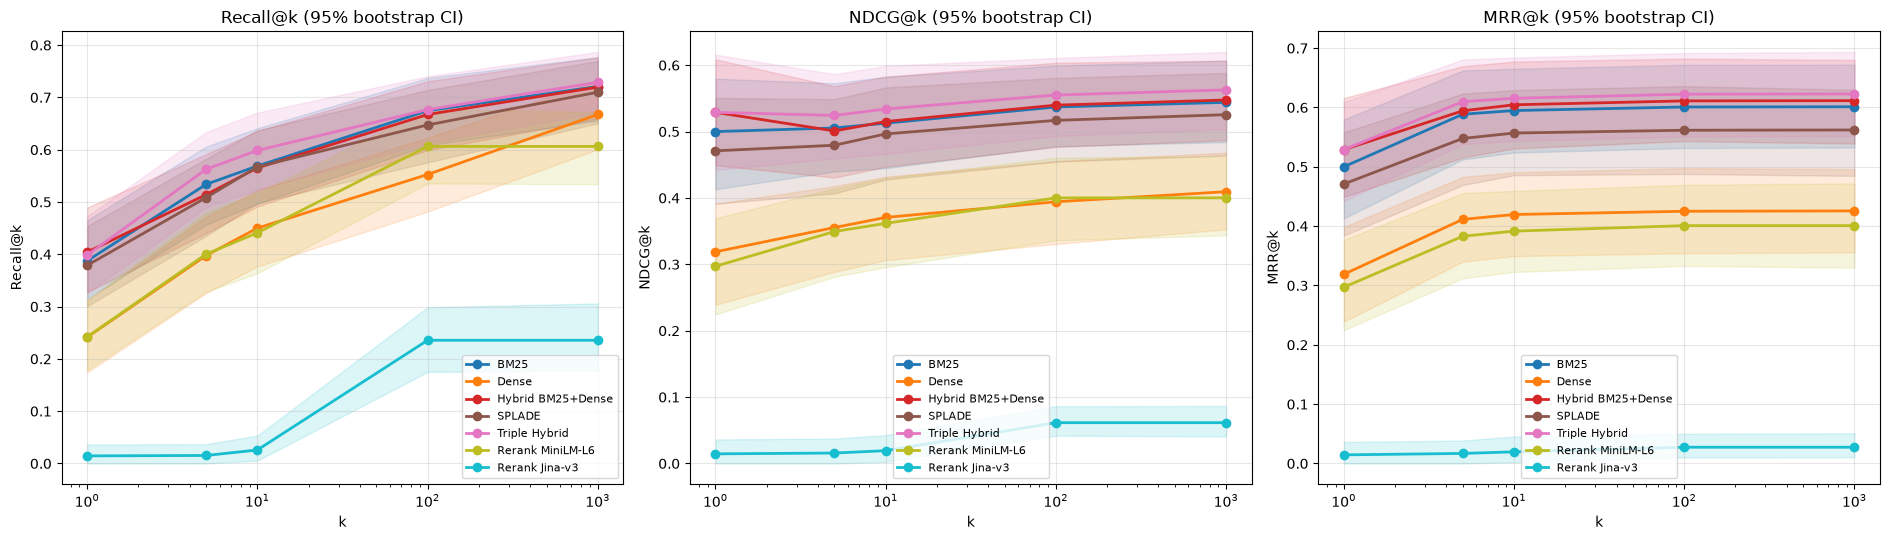

График сохранён: retrieval_analysis_plots/metrics_vs_k.png


In [ ]:
def plot_metrics_with_ci(per_query_by_method, k_values=K_VALUES, out_path=f"{OUT_DIR}/metrics_vs_k.png"):
    methods = list(per_query_by_method.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    for ax, metric in zip(axes, ["Recall", "NDCG", "MRR"]):
        for method, color in zip(methods, colors):
            means, ci_los, ci_his = [], [], []
            for k in k_values:
                vals = per_query_by_method[method][k][metric].to_numpy()
                boot_idx = np.random.randint(0, len(vals), size=(2000, len(vals)))
                boot_means = vals[boot_idx].mean(axis=1)
                lo, hi = np.percentile(boot_means, [2.5, 97.5])
                means.append(vals.mean())
                ci_los.append(lo)
                ci_his.append(hi)
            ax.plot(k_values, means, marker="o", label=method, color=color, linewidth=2)
            ax.fill_between(k_values, ci_los, ci_his, color=color, alpha=0.15)

        ax.set_xlabel("k")
        ax.set_ylabel(f"{metric}@k")
        ax.set_title(f"{metric}@k (95% bootstrap CI)")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_metrics_with_ci(per_query_by_method)

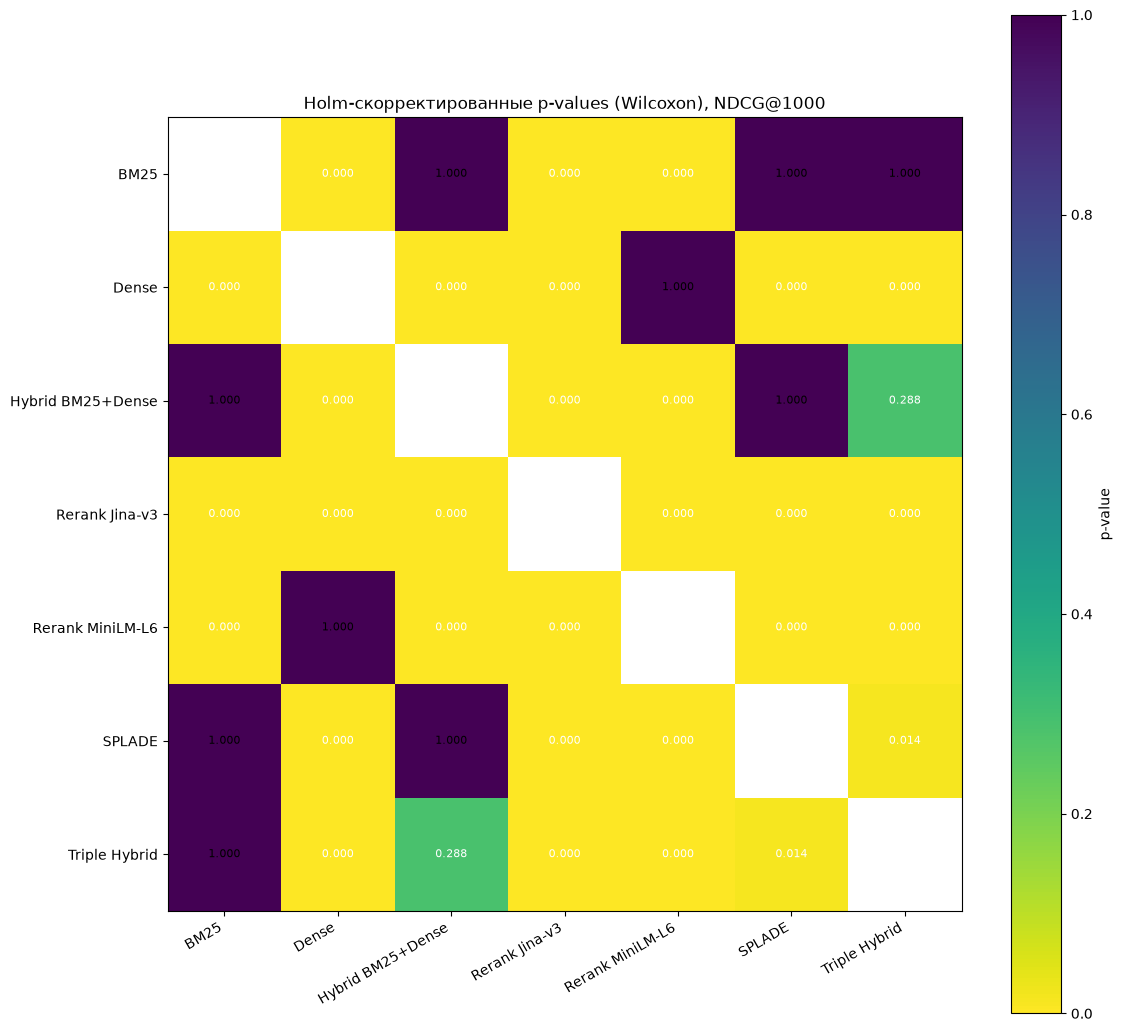

График сохранён: retrieval_analysis_plots/pvalue_heatmap_NDCG_at_k1000.png


In [ ]:
def plot_pvalue_heatmap(tests_df, k=10, metric="NDCG", out_path=None):
    if out_path is None:
        out_path = f"{OUT_DIR}/pvalue_heatmap_{metric}_at_k{k}.png"

    sub = tests_df[(tests_df["k"] == k) & (tests_df["metric"] == metric)]
    methods = sorted(set(sub["method_A"]) | set(sub["method_B"]))
    mat = pd.DataFrame(np.ones((len(methods), len(methods))), index=methods, columns=methods)
    for _, row in sub.iterrows():
        mat.loc[row["method_A"], row["method_B"]] = row["p_wilcoxon_holm"]
        mat.loc[row["method_B"], row["method_A"]] = row["p_wilcoxon_holm"]

    # Исправление: устанавливаем диагональ через iloc
    for i in range(len(methods)):
        mat.iloc[i, i] = np.nan

    fig, ax = plt.subplots(figsize=(1.4 * len(methods) + 2, 1.4 * len(methods) + 1))
    # mat.values может быть read-only, но мы используем mat.to_numpy() для imshow (это копия)
    im = ax.imshow(mat.to_numpy(dtype=float), cmap="viridis_r", vmin=0, vmax=1)
    ax.set_xticks(range(len(methods)))
    ax.set_yticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.set_yticklabels(methods)
    for i in range(len(methods)):
        for j in range(len(methods)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color="white" if val < 0.5 else "black", fontsize=8)
    ax.set_title(f"Holm-скорректированные p-values (Wilcoxon), {metric}@{k}")
    fig.colorbar(im, label="p-value")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_pvalue_heatmap(tests_df, k=1000, metric="NDCG")

## Метрики по типам вопросов

Средние по всем 138 запросам маскируют структуру провалов: часть типов вопросов (`intra_document_reasoning`, `completeness`, `conflicting_info`) требует не «более похожего чанка», а другой архитектуры (multi-hop, doc-level первый проход, recency/версионность), и ни ретривер, ни реранкер сами по себе это не чинят. Ниже — метрики отдельно по каждому `question_type`.

**Осторожно с размером групп.** Часть типов представлена очень малым числом вопросов (`conflicting_info`: 5, `miscellaneous`: 7, `intra_document_reasoning`/`constrained`: 10) — средние по ним шумные, а полноценные Wilcoxon-тесты внутри такой группы почти не имеют статистической мощности. Ниже приводится описательная разбивка (с `n_queries` в каждой ячейке), а не отдельные p-values по типам — делать далекоидущие выводы про конкретную группу из 5 вопросов не стоит, но сама картина (в каких типах разрыв между методами и в каких типах все методы одинаково слабы) уже информативна.

In [ ]:
# ==== Загрузка типов вопросов ====

def load_question_types():
    df_q = pd.read_parquet(QUESTIONS_PARQUET)
    candidates = ["question_type", "qtype", "type", "category"]
    col = next((c for c in candidates if c in df_q.columns), None)
    if col is None:
        raise KeyError(
            f"Не найдена колонка с типом вопроса. "
            f"Доступные колонки: {list(df_q.columns)}"
        )
    print(f"Колонка типа вопроса: '{col}'")
    qtype_by_qid = dict(zip(df_q["question_id"], df_q[col]))
    print("\nКоличество вопросов по типам:")
    print(df_q[col].value_counts())
    return qtype_by_qid

qtype_by_qid = load_question_types()

Колонка типа вопроса: 'question_type'

Количество вопросов по типам:
question_type
basic                       34
semantic                    30
project_related             24
completeness                18
intra_document_reasoning    10
constrained                 10
miscellaneous                7
conflicting_info             5
Name: count, dtype: int64


In [ ]:
# ==== Метрики по (метод, k, тип вопроса) ====

def metrics_by_qtype(per_query_by_method, qtype_by_qid, k_values=K_VALUES,
                      metrics=("Recall", "NDCG", "MRR")):
    rows = []
    for method, per_k in per_query_by_method.items():
        for k in k_values:
            df = per_k[k].copy()
            df["question_type"] = df.index.map(qtype_by_qid)
            for qtype, group in df.groupby("question_type", dropna=False):
                row = {"Method": method, "k": k, "question_type": qtype,
                       "n_queries": len(group)}
                for m in metrics:
                    row[m] = group[m].mean()
                rows.append(row)
    return pd.DataFrame(rows)

qtype_df = metrics_by_qtype(per_query_by_method, qtype_by_qid)

print("Число вопросов на (тип, метод) при k=10 — должно быть одинаковым по методам,\n"
      "если различается — где-то метод не покрывает часть qid (проверьте пересечение):")
display(
    qtype_df[qtype_df["k"] == 10]
    .pivot(index="question_type", columns="Method", values="n_queries")
)

Число вопросов на (тип, метод) при k=10 — должно быть одинаковым по методам,
если различается — где-то метод не покрывает часть qid (проверьте пересечение):


Method,BM25,Dense,Hybrid BM25+Dense,Rerank Jina-v3,Rerank MiniLM-L6,SPLADE,Triple Hybrid
question_type,,,,,,,
basic,34,34,34,34,34,34,34
completeness,18,18,18,18,18,18,18
conflicting_info,5,5,5,5,5,5,5
constrained,10,10,10,10,10,10,10
intra_document_reasoning,10,10,10,10,10,10,10
miscellaneous,7,7,7,7,7,7,7
project_related,24,24,24,24,24,24,24
semantic,30,30,30,30,30,30,30


In [ ]:
# ==== Таблицы метрик по типам вопросов ====

K_QTYPE_SHOW = 10  # основная точка отсечения для просмотра

for metric in ["Recall", "NDCG", "MRR"]:
    print(f"\n{metric}@{K_QTYPE_SHOW} по типам вопросов:")
    pivot = (
        qtype_df[qtype_df["k"] == K_QTYPE_SHOW]
        .pivot(index="question_type", columns="Method", values=metric)
    )
    # сортируем строки по среднему качеству, чтобы сразу видеть худшие типы наверху
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    display(pivot.round(3))

print(f"\nRecall@1000 по типам вопросов (потолок по recall для каждого типа):")
pivot_r1000 = (
    qtype_df[qtype_df["k"] == 1000]
    .pivot(index="question_type", columns="Method", values="Recall")
)
pivot_r1000 = pivot_r1000.loc[pivot_r1000.mean(axis=1).sort_values().index]
display(pivot_r1000.round(3))


Recall@10 по типам вопросов:


Method,BM25,Dense,Hybrid BM25+Dense,Rerank Jina-v3,Rerank MiniLM-L6,SPLADE,Triple Hybrid
question_type,,,,,,,
completeness,0.146,0.066,0.128,0.011,0.078,0.105,0.105
project_related,0.266,0.268,0.258,0.015,0.186,0.225,0.259
conflicting_info,0.300,0.200,0.300,0.000,0.300,0.400,0.300
semantic,0.567,0.367,0.533,0.067,0.367,0.633,0.633
constrained,0.700,0.650,0.700,0.000,0.450,0.600,0.700
basic,0.824,0.647,0.853,0.029,0.676,0.824,0.882
miscellaneous,0.857,0.857,1.000,0.000,0.857,0.857,1.000
intra_document_reasoning,1.000,0.800,0.900,0.000,0.900,1.000,1.000



NDCG@10 по типам вопросов:


Method,BM25,Dense,Hybrid BM25+Dense,Rerank Jina-v3,Rerank MiniLM-L6,SPLADE,Triple Hybrid
question_type,,,,,,,
completeness,0.204,0.094,0.182,0.006,0.084,0.129,0.144
project_related,0.287,0.283,0.300,0.010,0.207,0.256,0.324
conflicting_info,0.368,0.245,0.298,0.000,0.323,0.412,0.323
semantic,0.397,0.252,0.407,0.044,0.248,0.474,0.432
constrained,0.630,0.515,0.692,0.000,0.431,0.600,0.715
basic,0.738,0.477,0.761,0.029,0.522,0.688,0.779
intra_document_reasoning,0.906,0.702,0.796,0.000,0.685,0.876,0.849
miscellaneous,0.857,0.786,0.876,0.000,0.786,0.804,0.947



MRR@10 по типам вопросов:


Method,BM25,Dense,Hybrid BM25+Dense,Rerank Jina-v3,Rerank MiniLM-L6,SPLADE,Triple Hybrid
question_type,,,,,,,
semantic,0.345,0.215,0.370,0.038,0.210,0.424,0.369
completeness,0.492,0.241,0.451,0.008,0.172,0.282,0.333
conflicting_info,0.600,0.400,0.450,0.000,0.500,0.633,0.500
project_related,0.573,0.563,0.629,0.019,0.421,0.529,0.691
basic,0.709,0.425,0.732,0.029,0.471,0.647,0.744
constrained,0.725,0.514,0.850,0.000,0.450,0.733,0.900
intra_document_reasoning,0.875,0.670,0.764,0.000,0.618,0.833,0.800
miscellaneous,0.857,0.762,0.833,0.000,0.762,0.786,0.929



Recall@1000 по типам вопросов (потолок по recall для каждого типа):


Method,BM25,Dense,Hybrid BM25+Dense,Rerank Jina-v3,Rerank MiniLM-L6,SPLADE,Triple Hybrid
question_type,,,,,,,
completeness,0.185,0.137,0.177,0.011,0.149,0.168,0.192
project_related,0.319,0.298,0.319,0.138,0.271,0.310,0.319
conflicting_info,0.500,0.500,0.500,0.200,0.400,0.500,0.500
constrained,0.700,0.700,0.700,0.300,0.550,0.700,0.700
semantic,0.967,0.767,0.967,0.300,0.633,0.900,0.967
basic,0.971,0.971,0.971,0.265,0.912,1.000,1.000
miscellaneous,1.000,1.000,1.000,0.286,1.000,1.000,1.000
intra_document_reasoning,1.000,1.000,1.000,0.500,1.000,1.000,1.000


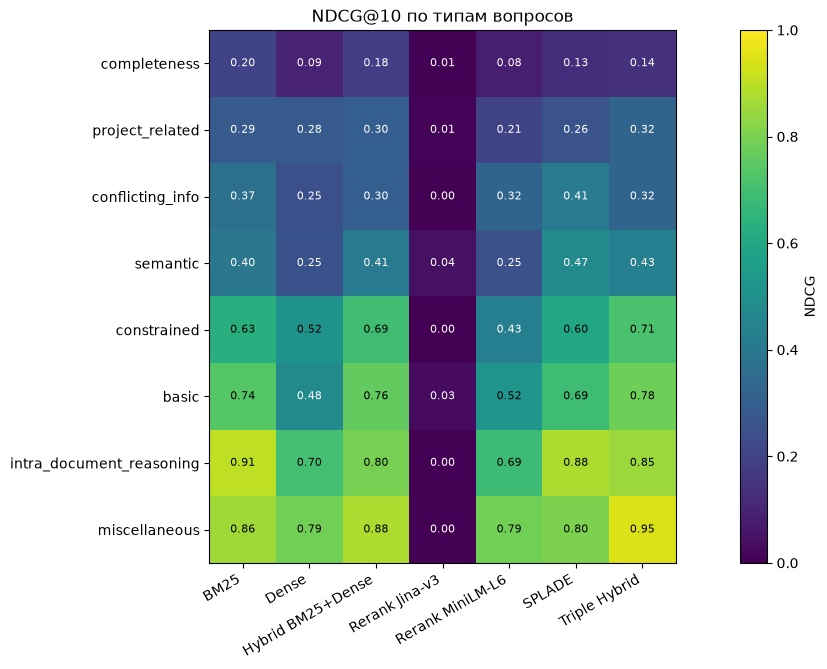

График сохранён: retrieval_analysis_plots/qtype_heatmap_NDCG_at_k10.png


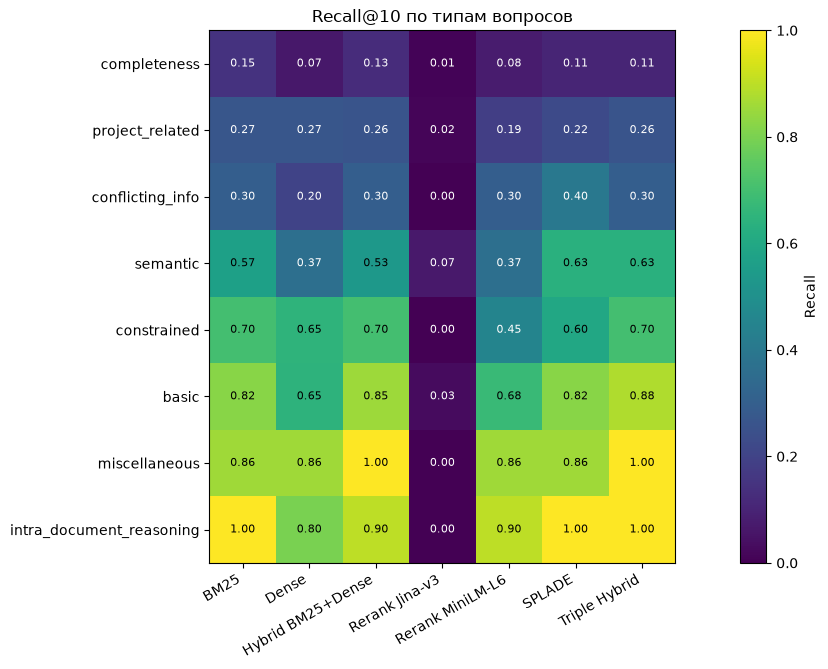

График сохранён: retrieval_analysis_plots/qtype_heatmap_Recall_at_k10.png


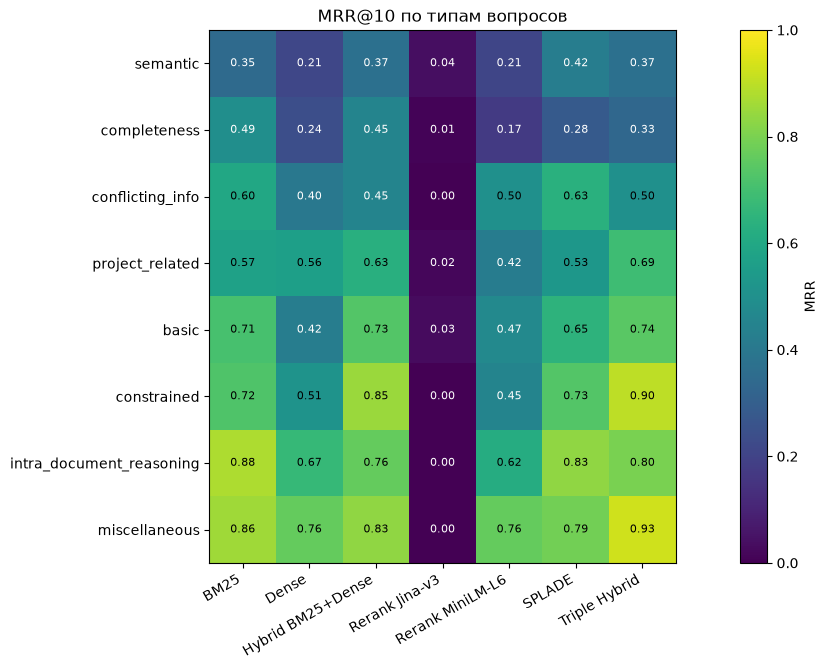

График сохранён: retrieval_analysis_plots/qtype_heatmap_MRR_at_k10.png


In [ ]:
# ==== Heatmap NDCG@10 по (метод x тип вопроса) ====

def plot_qtype_heatmap(qtype_df, k=10, metric="NDCG", out_path=None):
    if out_path is None:
        out_path = f"{OUT_DIR}/qtype_heatmap_{metric}_at_k{k}.png"

    sub = qtype_df[qtype_df["k"] == k]
    pivot = sub.pivot(index="question_type", columns="Method", values=metric)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(1.6 * len(pivot.columns) + 2, 0.6 * len(pivot.index) + 2))
    im = ax.imshow(pivot.to_numpy(dtype=float), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val < 0.5 else "black", fontsize=8)
    ax.set_title(f"{metric}@{k} по типам вопросов")
    fig.colorbar(im, label=metric)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_qtype_heatmap(qtype_df, k=10, metric="NDCG")
plot_qtype_heatmap(qtype_df, k=10, metric="Recall")
plot_qtype_heatmap(qtype_df, k=10, metric="MRR")